In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

#### Same logic as previous notebook but mixing the sample code provided by the course staff with my own code. The main difference is the structure of the data and the logic of the group where I previously grouped by user only, now it is by user label and by radar. I am now also aligning the radar data lengths before stacking.

In [260]:
dataset_path = os.path.realpath(
    os.path.join(
        os.getcwd(),
        "..",
        "Radar",
        "C3"
    )
)

In [261]:
emotions = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

#### Feature extraction helpers

In [262]:
def compute_trajectory_features(xyz, speed):
    trajectory_length = np.sum(speed)

    displacement = np.linalg.norm(xyz[-1] - xyz[0])

    path_efficiency = (
        displacement / trajectory_length
        if trajectory_length > 1e-6 else 0
    )

    mins = np.min(xyz, axis=0)
    maxs = np.max(xyz, axis=0)

    bounding_box_volume = np.prod(maxs - mins)

    return trajectory_length, displacement, path_efficiency, bounding_box_volume

In [263]:
def compute_motion_features(xyz):
    if len(xyz) >= 3:

        pca = PCA(n_components=3)
        pca.fit(xyz)

        movement_anisotropy = pca.explained_variance_ratio_[0]

    else:
        movement_anisotropy = 0

    return movement_anisotropy

In [264]:
def compute_turning_features(velocity_vectors):

    if len(velocity_vectors) >= 2:

        v1 = velocity_vectors[:-1]
        v2 = velocity_vectors[1:]

        norms1 = np.linalg.norm(v1, axis=1)
        norms2 = np.linalg.norm(v2, axis=1)

        valid = (norms1 > 1e-6) & (norms2 > 1e-6)

        if np.sum(valid) > 0:

            v1 = v1[valid]
            v2 = v2[valid]

            norms1 = norms1[valid]
            norms2 = norms2[valid]

            cos_angles = np.sum(v1 * v2, axis=1)

            cos_angles /= (norms1 * norms2)

            cos_angles = np.clip(cos_angles, -1, 1)

            angles = np.arccos(cos_angles)

            mean_turning_angle = np.mean(angles)

        else:
            mean_turning_angle = 0

    else:
        mean_turning_angle = 0

    return mean_turning_angle

In [265]:
def compute_motion_bursts(speed):

    threshold = np.mean(speed) + np.std(speed)

    active = speed > threshold

    motion_bursts = np.sum(
        np.diff(active.astype(int)) == 1
    )

    return motion_bursts

In [266]:
def compute_spectral_features(speed):
    spectrum = np.abs(np.fft.rfft(speed))

    freqs = np.fft.rfftfreq(len(speed))

    if len(spectrum) > 1:

        dominant_frequency = freqs[
            np.argmax(spectrum[1:]) + 1
        ]

        spectral_centroid = (
            np.sum(freqs * spectrum)
            / (np.sum(spectrum) + 1e-12)
        )

        psd = spectrum**2
        psd /= np.sum(psd) + 1e-12

        spectral_entropy = -np.sum(
            psd * np.log(psd + 1e-12)
        )

    else:

        dominant_frequency = 0
        spectral_centroid = 0
        spectral_entropy = 0

    return dominant_frequency, spectral_centroid, spectral_entropy

In [267]:
def distribution_features(signal):
    return [
        np.mean(signal),
        np.std(signal),
        np.median(signal),
        np.percentile(signal, 25),
        np.percentile(signal, 75)
    ]

In [268]:
from scipy.stats import skew, kurtosis, entropy

def tortuosity(xyz):
    path_length = np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))

    displacement = np.linalg.norm(xyz[-1] - xyz[0])

    if displacement == 0:
        return 1.0

    return path_length / displacement


def curvature(velocity, accel):
    v = velocity
    a = accel

    v = v[:-1]

    cross = np.linalg.norm(np.cross(v, a), axis=1)
    speed_mag = np.linalg.norm(v, axis=1)

    denom = speed_mag ** 3

    kappa = np.divide(
        cross,
        denom,
        out=np.zeros_like(cross),
        where=denom > 1e-8
    )

    return kappa


def curvature_features(velocity, accel):
    k = curvature(velocity, accel)
    
    return {
        "mean_curvature": np.mean(k),
        "median_curvature": np.median(k),
        "std_curvature": np.std(k),
        "curvature_entropy":
            entropy(np.histogram(k, bins=10)[0] + 1)
    }

def speed_shape_features(speed):
    s = speed

    return {
        "speed_skewness": skew(s),
        "speed_kurtosis": kurtosis(s)
    }

def acceleration_shape_features(accel):
    a = np.linalg.norm(accel, axis=1)

    return {
        "acc_skewness": skew(a),
        "acc_kurtosis": kurtosis(a)
    }

def jerk_shape_features(jerk):
    j = np.linalg.norm(jerk, axis=1)

    return {
        "jerk_skewness": skew(j),
        "jerk_kurtosis": kurtosis(j)
    }

from scipy.signal import welch

def spectral_energy_features(speed, fs=1.0):
    s = speed

    f, pxx = welch(s, fs=fs)

    total = np.sum(pxx)

    if total == 0:
        return {
            "dominant_frequency": 0,
            "low_freq_ratio": 0,
            "mid_freq_ratio": 0,
            "high_freq_ratio": 0
        }

    low = np.sum(pxx[f < 0.5])
    mid = np.sum(pxx[(f >= 0.5) & (f < 1.5)])
    high = np.sum(pxx[f >= 1.5])

    return {
        "dominant_frequency": f[np.argmax(pxx)],
        "low_freq_ratio": low / total,
        "mid_freq_ratio": mid / total,
        "high_freq_ratio": high / total
    }

def pause_features(speed, threshold=None):

    s = speed

    if threshold is None:
        threshold = 0.1 * np.median(s)

    paused = s < threshold

    runs = []
    current = 0

    for p in paused:
        if p:
            current += 1
        elif current > 0:
            runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    return {
        "pause_count": len(runs),
        "mean_pause_duration":
            np.mean(runs) if runs else 0,
        "pause_duration_cv":
            np.std(runs) / np.mean(runs)
            if len(runs) > 1 else 0,
        "fraction_stationary_time":
            np.mean(paused)
    }

def burst_features(speed):

    s = speed

    threshold = np.median(s) + np.std(s)

    bursts = s > threshold

    runs = []
    current = 0

    for b in bursts:
        if b:
            current += 1
        elif current > 0:
            runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    return {
        "burst_count": len(runs),
        "mean_burst_duration":
            np.mean(runs) if runs else 0,
        "burst_duration_cv":
            np.std(runs) / np.mean(runs)
            if len(runs) > 1 else 0
    }

def turning_features(velocity):

    v = velocity

    angles = []

    for i in range(len(v) - 1):

        a = v[i]
        b = v[i + 1]

        na = np.linalg.norm(a)
        nb = np.linalg.norm(b)

        if na == 0 or nb == 0:
            continue

        cos_theta = np.clip(
            np.dot(a, b) / (na * nb),
            -1,
            1
        )

        angles.append(np.degrees(np.arccos(cos_theta)))

    angles = np.array(angles)

    return {
        "mean_turn_angle": np.mean(angles),
        "std_turn_angle": np.std(angles),
        "turn_angle_entropy":
            entropy(np.histogram(angles, bins=10)[0] + 1),
        "large_turn_fraction":
            np.mean(angles > 45)
    }


def axis_coordination_features(xyz):

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    return {
        "corr_xy": np.corrcoef(x, y)[0, 1],
        "corr_xz": np.corrcoef(x, z)[0, 1],
        "corr_yz": np.corrcoef(y, z)[0, 1]
    }

def pca_features(xyz):

    pca = PCA(n_components=3)
    pca.fit(xyz)

    vr = pca.explained_variance_ratio_

    return {
        "explained_variance_ratio_1": vr[0],
        "explained_variance_ratio_2": vr[1],
        "explained_variance_ratio_3": vr[2],
        "anisotropy": vr[0] / vr[1]
            if vr[1] > 0 else 0
    }

from scipy.stats import iqr

def relative_features(speed, accel, jerk):

    s = speed
    a = accel
    j = jerk

    return {
        "speed_cv":
            np.std(s) / np.mean(s),

        "acc_cv":
            np.std(a) / np.mean(a),

        "jerk_cv":
            np.std(j) / np.mean(j),

        "speed_iqr_ratio":
            iqr(s) / np.median(s),

        "peak_to_median_speed":
            np.percentile(s, 90) / np.median(s)
    }

In [ ]:
feature_names = [
    # "trajectory_length",
    "displacement",
    "path_efficiency",
    # "bounding_box_volume",

    # "max_speed",
    # "max_acc",
    # "max_jerk",

    "mean_speed",
    "std_speed",
    # "median_speed",
    # "q25_speed",
    # "q75_speed",
    
    "mean_acc",
    "std_acc",
    # "median_acc",
    # "q25_acc",
    # "q75_acc",

    "mean_jerk",
    "std_jerk",
    # "median_jerk",
    # "q25_jerk",
    # "q75_jerk",

    # "motion_bursts",

    # "dominant_frequency",
    "spectral_centroid",
    "spectral_entropy",

    "speed_cv",
    "acceleration_sign_change",
    "direction_change_rate",
    # "speed_autocorr",

    "tortuosity",

    # "speed_skewness",
    # "speed_kurtosis",

    # "pause_count",
    # "fraction_stationary_time",

    "mean_turn_angle",
    "turn_angle_entropy",

    # "explained_variance_ratio_1",
    # "explained_variance_ratio_2",
    # "explained_variance_ratio_3"
]

def extract_features(xyz, include_list=feature_names):
    xyz = xyz.astype(np.float32)

    mean = np.mean(xyz, axis=0)
    std = np.std(xyz, axis=0)

    std[std < 1e-6] = 1.0

    xyz = (xyz - mean) / std
    
    velocity_vectors = np.diff(xyz, axis=0)
    acceleration_vectors = np.diff(velocity_vectors, axis=0)
    jerk_vectors = np.diff(acceleration_vectors, axis=0)
    speed = np.linalg.norm(velocity_vectors, axis=1)
    acc = np.linalg.norm(acceleration_vectors, axis=1)
    jerk = np.linalg.norm(jerk_vectors, axis=1)

    if len(speed) == 0:
        speed = np.array([0])

    if len(acceleration_vectors) == 0:
        acc = np.array([0])

    if len(jerk_vectors) == 0:
        jerk = np.array([0])

    trajectory_length, displacement, path_efficiency, bounding_box_volume = compute_trajectory_features(xyz, speed)
    mean_turning_angle = compute_turning_features(velocity_vectors)
    mean_speed, std_speed, median_speed, q25_speed, q75_speed = distribution_features(speed)
    mean_acc, std_acc, median_acc, q25_acc, q75_acc = distribution_features(acc)
    mean_jerk, std_jerk, median_jerk, q25_jerk, q75_jerk = distribution_features(jerk)
    motion_bursts = compute_motion_bursts(speed)
    dominant_frequency, spectral_centroid, spectral_entropy = compute_spectral_features(speed)
    tortuosity_value = tortuosity(xyz)
    mean_curvature, median_curvature, std_curvature, curvature_entropy = curvature_features(velocity_vectors, acceleration_vectors).values()
    speed_skewness, speed_kurtosis = speed_shape_features(speed).values()
    acc_skewness, acc_kurtosis = acceleration_shape_features(acceleration_vectors).values()
    jerk_skewness, jerk_kurtosis = jerk_shape_features(jerk_vectors).values()
    _, low_freq_ratio, mid_freq_ratio, high_freq_ratio = spectral_energy_features(speed).values()
    pause_count, mean_pause_duration, pause_duration_cv, fraction_stationary_time = pause_features(speed).values()
    burst_count, mean_burst_duration, burst_duration_cv = burst_features(speed).values()
    mean_turn_angle, std_turn_angle, turn_angle_entropy, large_turn_fraction = turning_features(velocity_vectors).values()
    corr_xy, corr_xz, corr_yz = axis_coordination_features(xyz).values()
    explained_variance_ratio_1, explained_variance_ratio_2, explained_variance_ratio_3, anisotropy = pca_features(xyz).values()
    speed_cv, acc_cv, jerk_cv, speed_iqr_ratio, peak_to_median_speed = relative_features(speed, acc, jerk).values() 
    
    features = np.array([])

    if "trajectory_length" in include_list:
        features = np.append(features, trajectory_length)
    if "displacement" in include_list:
        features = np.append(features, displacement)
    if "path_efficiency" in include_list:
        features = np.append(features, path_efficiency)
    if "bounding_box_volume" in include_list:
        features = np.append(features, bounding_box_volume)
    if "mean_turning_angle" in include_list:
        features = np.append(features, mean_turning_angle)
    if "mean_speed" in include_list:
        features = np.append(features, mean_speed)
    if "std_speed" in include_list:
        features = np.append(features, std_speed)
    if "median_speed" in include_list:
        features = np.append(features, median_speed)
    if "q25_speed" in include_list:
        features = np.append(features, q25_speed)
    if "q75_speed" in include_list:
        features = np.append(features, q75_speed)
    if "mean_acc" in include_list:
        features = np.append(features, mean_acc)
    if "std_acc" in include_list:
        features = np.append(features, std_acc)
    if "median_acc" in include_list:
        features = np.append(features, median_acc)
    if "q25_acc" in include_list:
        features = np.append(features, q25_acc)
    if "q75_acc" in include_list:
        features = np.append(features, q75_acc)
    if "mean_jerk" in include_list:
        features = np.append(features, mean_jerk)
    if "std_jerk" in include_list:
        features = np.append(features, std_jerk)
    if "median_jerk" in include_list:
        features = np.append(features, median_jerk)
    if "q25_jerk" in include_list:
        features = np.append(features, q25_jerk)
    if "q75_jerk" in include_list:
        features = np.append(features, q75_jerk)

    if "spectral_entropy" in include_list:
        features = np.append(features, spectral_entropy)
    if "spectral_centroid" in include_list:
        features = np.append(features, spectral_centroid)

    if "speed_cv" in include_list:
        features = np.append(features, speed_cv)

    if "acceleration_sign_change" in include_list:
        acc_sign_changes = np.sum(
            np.diff(np.sign(acceleration_vectors)) != 0
        )
        acc_sign_changes /= len(acceleration_vectors)
        features = np.append(features, acc_sign_changes)

    if "direction_change_rate" in include_list:
        velocity_norm = np.linalg.norm(velocity_vectors, axis=1, keepdims=True) + 1e-6
        velocity_unit = velocity_vectors / velocity_norm

        direction_similarity = np.sum(
            velocity_unit[:-1] * velocity_unit[1:],
            axis=1
        )

        direction_change_rate = np.mean(1 - direction_similarity)
        features = np.append(features, direction_change_rate)

    if "tortuosity" in include_list:
        features = np.append(features, tortuosity_value)
    
    if "speed_skewness" in include_list:
        features = np.append(features, speed_skewness)
    if "speed_kurtosis" in include_list:
        features = np.append(features, speed_kurtosis)

    if "pause_count" in include_list:
        features = np.append(features, pause_count)
    if "fraction_stationary_time" in include_list:
        features = np.append(features, fraction_stationary_time)

    if "mean_turn_angle" in include_list:
        features = np.append(features, mean_turn_angle)
    if "turn_angle_entropy" in include_list:
        features = np.append(features, turn_angle_entropy)

    if "explained_variance_ratio_1" in include_list:
        features = np.append(features, explained_variance_ratio_1)
    if "explained_variance_ratio_2" in include_list:
        features = np.append(features, explained_variance_ratio_2)
    if "explained_variance_ratio_3" in include_list:
        features = np.append(features, explained_variance_ratio_3)

    if "speed_autocorr" in include_list:
        speed_autocorr = np.corrcoef(speed[:-1], speed[1:])[0, 1]
        features = np.append(features, speed_autocorr)


    return features

In [270]:
from typing import List, Tuple, Union, Optional

NUM_RADARS = 13

def _align_radar_lengths(radar_data_list: List[np.ndarray]) -> List[np.ndarray]:
    lengths = [d.shape[0] for d in radar_data_list]
    min_len = min(lengths)
    return [d[:min_len] for d in radar_data_list]

def preprocess(
    data_dir: str,
    events: list[str]
) -> Union[Tuple[List[np.ndarray], np.ndarray, np.ndarray], Tuple[None, None, None]]:
    if not os.path.exists(data_dir):
        print(f"{data_dir} is not a valid directory")
        return None, None, None

    raw_data = []
    allowed_events = set(events)

    for u in os.listdir(data_dir):
        if not u.startswith("U"):
            continue

        for e in os.listdir(os.path.join(data_dir, u)):
            if not e.startswith("E"):
                continue

            if e not in allowed_events:
                continue
            
            emotion_label = emotions[e]

            radar_folder = os.listdir(os.path.join(data_dir, u, e))
            trial_idx = None
            
            for f in radar_folder:

                dir_path = os.path.join(dataset_path, u, e, f)

                if os.path.isdir(dir_path):

                    radar_files = os.listdir(dir_path)

                    trial_idx = f
                    break

            dir_path = os.path.join(data_dir, u, e, trial_idx)
            

            for f in radar_files:
                file_path = os.path.join(data_dir, u, e, trial_idx, f)
                data = pd.read_pickle(file_path)
                radar_used = "CEILING" if int(f[0]) < 5 else "GROUND"
                sequence = np.vstack(data)

                fs = []
                for s in sequence:

                    xyz = [s[1], s[2], s[3]]
                    if radar_used == "CEILING":
                        xyz = [s[3], s[2], -s[1]]

                    new_s = xyz
                    fs.append(new_s)

                fs = np.array(fs)
                raw_data.append(
                    {
                        "data": fs,
                        "user": u,
                        "label": emotion_label,
                        "trial": trial_idx,
                        "radar": f[0],
                    }
                )
    
    data_list: list[np.ndarray] = []
    labels_list: list[str] = []
    users_list: list[str] = []

    grouped: dict[tuple[str, str, int], list[dict]] = {}
    for item in raw_data:
        key = (item["user"], item["label"], item["trial"])
        grouped.setdefault(key, []).append(item)

    for (u, l, _), group in grouped.items():
        group = sorted(group, key=lambda x: x["radar"])
        radar_data_list = [g["data"] for g in group]
        if len(radar_data_list) != NUM_RADARS:
            continue
        aligned_radars = _align_radar_lengths(radar_data_list)

        sample = np.stack(aligned_radars, axis=0).astype(np.float32)
        data_list.append(sample)
        labels_list.append(l)
        users_list.append(u)

    labels = np.asarray(labels_list)
    users = np.asarray(users_list)

    print(f"final count: data {len(data_list)}, labels {labels.shape}, users {users.shape}")
    return data_list, labels, users

In [271]:
preprocessed_data, labels, users = preprocess(dataset_path, list(emotions.keys()))

final count: data 156, labels (156,), users (156,)


#### Exploring using a window of 15 frames to extract features from instead of the entire frame.

In [272]:
WINDOW_SIZE = 60
STRIDE = 15

In [273]:
def build_windows(
    data: Union[np.ndarray, List[np.ndarray]],
    labels: np.ndarray,
    users: np.ndarray,
) -> Optional[str]:
    samples = list(data) if not (isinstance(data, np.ndarray) and data.dtype != object) else [data[i] for i in range(data.shape[0])]

    win_frames = WINDOW_SIZE
    stride = STRIDE

    X_list: list[np.ndarray] = []
    y_list: list[str] = []
    u_list: list[str] = []

    for i, sample in enumerate(samples):
        if sample is None:
            continue
        _, frames, _ = sample.shape

        if win_frames > frames:
            continue

        for start in range(0, frames - win_frames + 1, stride):
            end = start + win_frames
            n_window = sample[:, start:end, :]
            X_list.append(n_window)
            y_list.append(labels[i])
            u_list.append(users[i])

    X = np.stack(X_list).astype(np.float32)

    y = np.asarray(y_list)
    u = np.asarray(u_list)

    return X, y, u

In [274]:
X, y, u = build_windows(preprocessed_data, labels, users)

In [275]:
def build_radar_feature_dataset(X, feature_fn, include_list=feature_names):
    N, R, T, C = X.shape

    X_feat = []

    for i in range(N):
        sample = X[i]

        radar_feats = []
        valid = True

        for r in range(R):
            seq = sample[r]

            if seq is None or seq.shape[0] < 3:
                valid = False
                break

            # seq = (seq - seq.mean(axis=0)) / (seq.std(axis=0) + 1e-6)
            feat = feature_fn(seq, include_list)

            if feat is None:
                valid = False
                break

            radar_feats.append(feat)

        if not valid:
            continue

        radar_feats = np.concatenate(radar_feats, axis=0)
        X_feat.append(radar_feats)

    X_feat = np.asarray(X_feat, dtype=np.float32)

    return X_feat

In [276]:
X_feature = build_radar_feature_dataset(X, extract_features)

In [277]:
X_feature.shape

(655, 195)

In [315]:
from joblib import Parallel, delayed

def extract_all_radars_parallel(X_windows, include_list=feature_names, n_jobs=-1):
    n_windows, n_radars, _, _ = X_windows.shape
    n_features = len(extract_features(X_windows[0, 0], include_list=include_list))

    def extract_window(i):
        row = np.zeros((n_radars, n_features), dtype=np.float32)
        for r in range(n_radars):
            row[r] = extract_features(X_windows[i, r], include_list=include_list)
        return row

    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(extract_window)(i) for i in range(n_windows)
    )
    return np.stack(results)

In [316]:
def aggregate_radar_features(X_per_radar: np.ndarray, include_list=feature_names) -> pd.DataFrame:
    cols = {}
    for feat_idx, feat_name in enumerate(include_list):
        vals = X_per_radar[:, :, feat_idx]      
        cols[f"{feat_name}_mean"] = vals.mean(axis=1)
        cols[f"{feat_name}_std"]  = vals.std(axis=1)
        cols[f"{feat_name}_min"]  = vals.min(axis=1)
        cols[f"{feat_name}_max"]  = vals.max(axis=1)
    
    return pd.DataFrame(cols)

In [317]:
def normalize_per_subject(X: pd.DataFrame, groups: np.ndarray) -> pd.DataFrame:
    X_norm = X.copy()
    for subject in np.unique(groups):
        mask = groups == subject
        means = X_norm.loc[mask].mean()
        stds  = X_norm.loc[mask].std().replace(0, 1)
        X_norm.loc[mask] = (X_norm.loc[mask] - means) / stds
    return X_norm

In [318]:
X_per_radar = extract_all_radars_parallel(X, include_list=feature_names)

In [319]:
X_agg = aggregate_radar_features(X_per_radar, include_list=feature_names)

In [320]:
X_norm = normalize_per_subject(X_agg, groups=u)

In [321]:
X_norm.shape

(655, 60)

In [280]:
X_feature_mean = np.array([extract_features(x.mean(axis=0)) for x in X])

In [281]:
X_feature_mean.shape

(655, 15)

In [282]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report

def train_rf_with_feature_selection(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        max_depth=None
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print("=== Full model performance ===")
    print(classification_report(y_test, y_pred))

    importances = rf.feature_importances_

    threshold = np.mean(importances)

    selector = SelectFromModel(rf, threshold=threshold, prefit=True)

    return rf, selector, importances

In [283]:
rf, selector, importances = train_rf_with_feature_selection(X_feature, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.83      0.73      0.78        26
 distraction       0.81      0.72      0.76        18
  excitement       0.65      0.96      0.77        55
       focus       1.00      0.14      0.25        14
  relaxation       0.00      0.00      0.00         3
      stress       0.75      0.40      0.52        15

    accuracy                           0.71       131
   macro avg       0.67      0.49      0.51       131
weighted avg       0.74      0.71      0.67       131



In [284]:
rf_mean, selector_mean, importances_mean = train_rf_with_feature_selection(X_feature_mean, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.50      0.35      0.41        26
 distraction       0.56      0.56      0.56        18
  excitement       0.62      0.82      0.71        55
       focus       0.38      0.36      0.37        14
  relaxation       0.00      0.00      0.00         3
      stress       0.30      0.20      0.24        15

    accuracy                           0.55       131
   macro avg       0.39      0.38      0.38       131
weighted avg       0.51      0.55      0.52       131



In [285]:
len(feature_names)

15

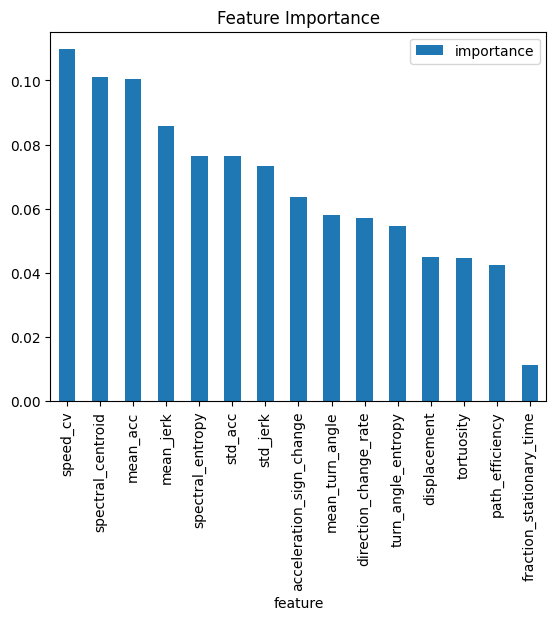

In [286]:
df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_mean
}).sort_values(by="importance", ascending=False)


df.plot.bar(x="feature", y="importance")
plt.title("Feature Importance")
plt.show()

In [287]:
include_list = df["feature"].tolist()[:7]
# include_list = feature_names
# include_list

In [288]:
X_feature_filtered = build_radar_feature_dataset(X, extract_features, include_list)

In [289]:
X_feature_filtered.shape

(655, 91)

In [290]:
rf_filtered, selector_filtered, importances_filtered = train_rf_with_feature_selection(X_feature_filtered, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.92      0.85      0.88        26
 distraction       0.76      0.89      0.82        18
  excitement       0.79      0.98      0.88        55
       focus       0.86      0.43      0.57        14
  relaxation       1.00      0.33      0.50         3
      stress       0.80      0.53      0.64        15

    accuracy                           0.82       131
   macro avg       0.85      0.67      0.71       131
weighted avg       0.83      0.82      0.80       131



In [291]:
np.savez_compressed(
    "radar_features_filtered.npz",
    X=X_feature_filtered.astype(np.float32),
    y=y,
    u=u
)

In [328]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

def anova_ranking(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray) -> pd.DataFrame:
    logo = LeaveOneGroupOut()
    records = []
    low_variance_skip = 0
    infinite_skip = 0

    for col in X.columns:
        fold_f_stats = []
        for train_idx, _ in logo.split(X, y, groups):
            y_train = y[train_idx]
            x_train = X[col].values[train_idx]

            if np.std(x_train) < 1e-6:
                print("skipped feature due to low variance:", col)
                low_variance_skip += 1
                continue

            group_vals = [x_train[y_train == cls] for cls in np.unique(y_train)]
            group_vals = [g for g in group_vals if len(g) > 0 and np.std(g) > 1e-6]  # ← skip flat groups

            if len(group_vals) < 2:
                continue

            f_stat, _ = stats.f_oneway(*group_vals)

            if np.isfinite(f_stat): 
                fold_f_stats.append(f_stat)
            else:
                print("skipped feature due to non-finite F-statistic:", col)
                infinite_skip += 1

        records.append({
            "feature": col,
            "F_statistic": np.mean(fold_f_stats) if fold_f_stats else np.nan
        })

    print(f"Skipped {low_variance_skip} features due to low variance.")
    print(f"Skipped {infinite_skip} features due to non-finite F-statistic.")

    ranking = (
        pd.DataFrame(records)
        .sort_values("F_statistic", ascending=False)
        .reset_index(drop=True)
    )
    ranking.index += 1
    ranking.index.name = "rank"
    return ranking

In [329]:
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from joblib import Parallel, delayed

def sffs_fast(
    X: pd.DataFrame,
    y: np.ndarray,
    groups: np.ndarray,    
    feature_order: list,   
    scoring: str = "f1_macro",
    max_features: int = 15,
    anova_top_k: int = 30,
    n_jobs: int = -1,
):  
    estimator = CatBoostClassifier(verbose=0)

    logo = LeaveOneGroupOut()
    feature_order = feature_order[:anova_top_k]
    score_cache = {}

    def score_subset(features):
        key = frozenset(features)
        if key not in score_cache:
            score_cache[key] = cross_val_score(
                clone(estimator), X[list(features)], y,
                cv=logo,
                groups=groups,      
                scoring=scoring,
                n_jobs=1,
            ).mean()
        return score_cache[key]

    def eval_candidates(candidates, current_selected, mode="add"):
        def _eval(feat):
            subset = current_selected + [feat] if mode == "add" else [f for f in current_selected if f != feat]
            return feat, score_subset(subset)
        return Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(_eval)(feat) for feat in candidates
        )

    selected, remaining, blacklist = [], list(feature_order), set()
    best_global_score, best_global_subset = -np.inf, []

    while remaining and len(selected) < max_features:
        candidates = [f for f in remaining if f not in blacklist]
        if not candidates:
            print("  No valid candidates — stopping.")
            break

        results = eval_candidates(candidates, selected, mode="add")
        best_add_feature, best_add_score = max(results, key=lambda x: x[1])

        selected.append(best_add_feature)
        remaining.remove(best_add_feature)
        current_score = best_add_score
        snapshot = selected.copy()
        print(f"  [+] '{best_add_feature}'  →  {scoring}: {current_score:.4f}  |  {len(selected)} features")

        if current_score > best_global_score:
            best_global_score, best_global_subset = current_score, selected.copy()

        if len(selected) <= 2:
            continue

        improved = True
        while improved and len(selected) > 2:
            improved = False
            results = eval_candidates(selected, selected, mode="remove")
            worst_feature, best_removal_score = max(results, key=lambda x: x[1])

            if best_removal_score > current_score:
                selected.remove(worst_feature)
                current_score = best_removal_score
                improved = True
                print(f"  [-] '{worst_feature}'  →  {scoring}: {current_score:.4f}  |  {len(selected)} features")

                if current_score > best_global_score:
                    best_global_score, best_global_subset = current_score, selected.copy()

                if sorted(selected) == sorted(snapshot[:-1]):
                    culprit = snapshot[-1]
                    print(f"  [!] Cycle — blacklisting '{culprit}'")
                    blacklist.add(culprit)
                    if culprit in selected:
                        selected.remove(culprit)
                    remaining.append(culprit)
                    break

    print(f"\nBest subset : {best_global_subset}")
    print(f"Best score  : {best_global_score:.4f}")
    return best_global_subset, best_global_score

In [ ]:
ranking = anova_ranking(X_norm, y, groups=u)
print(ranking.to_string())

valid = ranking.dropna(subset=["F_statistic"])
ordered_features = valid["feature"].tolist()

best_subset, best_score = sffs_fast(
    X_norm, 
    y,
    groups=u,                   
    feature_order=ordered_features,
)

Skipped 0 features due to low variance.
Skipped 0 features due to non-finite F-statistic.
                            feature  F_statistic
rank                                            
1     acceleration_sign_change_mean    13.842953
2      acceleration_sign_change_max     9.583142
3             spectral_entropy_mean     6.647583
4           turn_angle_entropy_mean     6.359302
5     fraction_stationary_time_mean     6.230336
6      acceleration_sign_change_min     5.009526
7              spectral_entropy_std     4.819481
8        direction_change_rate_mean     4.639920
9              mean_turn_angle_mean     4.526004
10                      std_acc_std     4.348271
11                    mean_jerk_std     4.280841
12                     mean_acc_std     4.145173
13                     std_jerk_std     4.055289
14              path_efficiency_min     4.032505
15                 displacement_min     3.549723
16        direction_change_rate_max     3.429954
17             spectral_entr

KeyboardInterrupt: 

#### While using this data for models provided good results for random split, it was inneficient for user-wise split. I will try to use the same logic but this time manually pick out the features that I think are relevant and that are not too user-specific to keep the model from overfitting to the users in the training set.

In [ ]:
# include_list_manual = [
#     "spectral_entropy",
#     "spectral_centroid",

#     "mean_turning_angle",
#     "path_efficiency",
#     "motion_bursts",
# ]

In [ ]:
# X_feature_filtered_manual = build_radar_feature_dataset(
#     X, extract_features, include_list_manual
# )

In [ ]:
# np.savez_compressed(
#     "radar_features_filtered_manual.npz",
#     X=X_feature_filtered_manual.astype(np.float32),
#     y=y,
#     u=u
# )

#### The manually picked features actually perform worse than the filtered set of features.